In [1]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import set_seed, AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [2]:
set_seed(42)

In [3]:
data = load_dataset("csv", data_files="Suicidal Ideation Dataset.csv")
data = data["train"].train_test_split(test_size=0.2, seed=42)
data

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Index', 'Posts', 'Suicidal1', 'Suicidal2'],
        num_rows: 400
    })
    test: Dataset({
        features: ['Index', 'Posts', 'Suicidal1', 'Suicidal2'],
        num_rows: 100
    })
})

In [4]:
data_tag1 = data.remove_columns(["Suicidal2"])
data_tag1

DatasetDict({
    train: Dataset({
        features: ['Index', 'Posts', 'Suicidal1'],
        num_rows: 400
    })
    test: Dataset({
        features: ['Index', 'Posts', 'Suicidal1'],
        num_rows: 100
    })
})

In [5]:
data_tag2 = data.remove_columns(["Suicidal1"])
data_tag2

DatasetDict({
    train: Dataset({
        features: ['Index', 'Posts', 'Suicidal2'],
        num_rows: 400
    })
    test: Dataset({
        features: ['Index', 'Posts', 'Suicidal2'],
        num_rows: 100
    })
})

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
id2label = {0: "Non-Suicidal", 1: "Suicidal"}
label2id = {"Non-Suicidal": 0, "Suicidal": 1}

config = AutoConfig.from_pretrained("distilbert-base-uncased") # change model name here
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2
config.num_labels = 2
config.id2label = id2label
config.label2id = label2id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [8]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config) # change model name here
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # change model name here
model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [9]:
print(model.config)
model.classifier

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "attention_probs_dropout_prob": 0.2,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "hidden_dropout_prob": 0.2,
  "id2label": {
    "0": "Non-Suicidal",
    "1": "Suicidal"
  },
  "initializer_range": 0.02,
  "label2id": {
    "Non-Suicidal": 0,
    "Suicidal": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}



Linear(in_features=768, out_features=2, bias=True)

In [10]:
def tokenize_dataset(examples):
    return tokenizer(
        examples["Posts"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [11]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions),
            "f1": f1_score(labels, predictions)}

In [12]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [13]:
def calibrate_threshold(labels, probs):
    thresholds = np.arange(0, 1, 0.001)
    f1_scores = [f1_score(labels, (probs >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    return best_threshold, f1_scores[best_idx]

In [14]:
tokenized_dataset = data_tag1.map(tokenize_dataset, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("Suicidal1", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset = tokenized_dataset["train"]
val_dataset = tokenized_dataset["test"]
train_dataset

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['Index', 'Posts', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 400
})

In [15]:
train_labels = np.array(train_dataset['labels'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
norm_weights = np.sqrt(class_weights)
norm_weights = (norm_weights / norm_weights.sum()) * len(np.unique(train_labels))
#norm_weights = (class_weights / class_weights.sum()) * len(np.unique(train_labels))

weight_vector = torch.tensor(norm_weights, dtype=torch.float).to(device)
weight_vector

tensor([0.6155, 1.3845], device='cuda:0')

In [16]:
training_args = TrainingArguments(
    output_dir='./outputs',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=len(val_dataset),
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=1e-5,
    weight_decay=0.4,
    warmup_steps=15,
    load_best_model_at_end=True,
    greater_is_better=True,
    metric_for_best_model="f1",
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    processing_class=tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=weight_vector,
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.394336,0.890000,0.421053
2,No log,0.348350,0.860000,0.562500
3,No log,0.361233,0.880000,0.625000
4,No log,0.368814,0.890000,0.620690
5,No log,0.360797,0.910000,0.689655
6,No log,0.395476,0.910000,0.689655
7,No log,0.402209,0.910000,0.689655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=350, training_loss=0.24963387625558037, metrics={'train_runtime': 75.406, 'train_samples_per_second': 53.046, 'train_steps_per_second': 6.631, 'total_flos': 92727179059200.0, 'train_loss': 0.24963387625558037, 'epoch': 7.0})

In [18]:
trainer.train()

log_history_1 = trainer.state.log_history.copy()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.406848,0.910000,0.689655
2,No log,0.493716,0.910000,0.689655
3,No log,0.482839,0.910000,0.689655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [77]:
print(trainer.optimizer)
print(trainer.lr_scheduler)

AcceleratedOptimizer (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    initial_lr: 5e-05
    lr: 0.0
    maximize: False
    weight_decay: 0.0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    initial_lr: 5e-05
    lr: 0.0
    maximize: False
    weight_decay: 0.0
)


In [78]:
predictions = trainer.predict(val_dataset)
logits = torch.from_numpy(predictions.predictions)
probs = torch.nn.functional.softmax(logits, dim=-1)[:, 1].numpy()
labels = predictions.label_ids

threshold, best_f1= calibrate_threshold(labels, probs)
preds = (probs >= threshold).astype(int)

print(f"Optimal Threshold: {threshold}")

Optimal Threshold: 0.037


In [79]:
target_names = [id2label[0], id2label[1]]
print(f"Classification Report: \n{classification_report(labels, preds, target_names=target_names)}")

Classification Report: 
              precision    recall  f1-score   support

Non-Suicidal       0.97      0.88      0.93        84
    Suicidal       0.58      0.88      0.70        16

    accuracy                           0.88       100
   macro avg       0.78      0.88      0.81       100
weighted avg       0.91      0.88      0.89       100



In [80]:
from datasets import load_dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score


dataset = load_dataset("csv", data_files="Suicidal Ideation Dataset.csv")
dataset = dataset["train"].train_test_split(test_size=0.20)

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)


def preprocess_function_1(examples):
    examples["labels"] = examples["Suicidal1"]
    return tokenizer(examples["Posts"], truncation=True, padding="max_length", max_length=512)

processed_dataset_1 = dataset.map(preprocess_function_1, batched=True)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


training_args_1 = TrainingArguments(
    output_dir="./results_distilbert_suicidal1",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    #evaluation_strategy="epoch",   # works if transformers is updated
    report_to="none",
)


trainer_1 = Trainer(
    model=model,
    args=training_args_1,
    train_dataset=processed_dataset_1["train"],
    eval_dataset=processed_dataset_1["test"],
    compute_metrics=compute_metrics,
)

print("Starting training for DistilBERT - Suicidal1...")
trainer_1.train()

results_1 = trainer_1.evaluate()
print(f"Final evaluation for DistilBERT - Suicidal1: {results_1}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training for DistilBERT - Suicidal1...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final evaluation for DistilBERT - Suicidal1: {'eval_loss': 0.31787940859794617, 'eval_accuracy': 0.91, 'eval_runtime': 1.6132, 'eval_samples_per_second': 61.989, 'eval_steps_per_second': 8.059, 'epoch': 3.0}


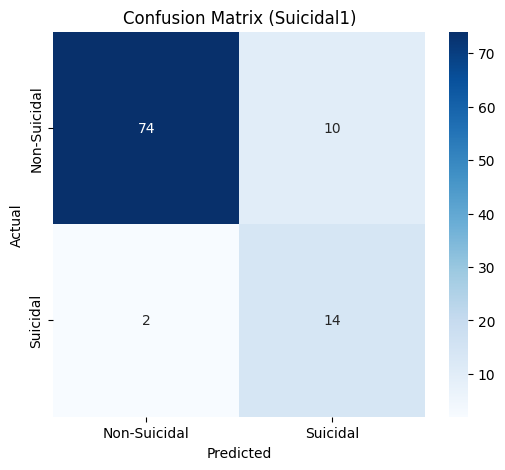

In [81]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Suicidal1)')
plt.show()

In [82]:
predictions = trainer.predict(val_dataset)
import numpy as np
import torch.nn.functional as F

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits → probabilities
probs = F.softmax(torch.tensor(logits), dim=1).numpy()

# We only need suicidal class probability (class 1)
model_probs = probs[:, 1]
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, model_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = f1_scores.argmax()
threshold = thresholds[best_idx]

print("Best Threshold:", threshold)
def predict(text, model, tokenizer, id2label):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)

        suicidal_prob = probs[0, 1].item()

        if suicidal_prob >= threshold:
            prediction = 1
        elif suicidal_prob >= (threshold - 0.08):   # soft zone
            prediction = 1
        else:
            prediction = 0

    return id2label[prediction]


Best Threshold: 0.039088357


In [83]:
def predict(text, model, tokenizer, id2label):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        suicidal_prob = probs[0, 1].item()
        prediction = 1 if suicidal_prob >= threshold else 0

    return id2label[prediction]

In [84]:
text = ("I am feeling very overwhelmed and hopeless lately.", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I have nothing left to live fr... i just want to end this and sleep forever!", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I’m not planning anything, but if a car suddenly swerved toward me today, I wouldn't move out of the way.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I am moving to the edge of the cliff, i have to do this for the betterment of others... i have to jmp frm here, i shall join the squad back after i respawn.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I want to die.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("Just another bad day at work!", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("meet me at the battle arena, if i can't prove as MVP i shall commit suicide...", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("Broo! frr what u say this???? i hrd SSR commited suicide!", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("""everyday i start out, then i cry my heart out, lonely is a man without love... - suits so damn well, but this phrasal life is becoming too
suffocating now and i don't think i can make myself work with this on this world anymore... its just too much! when u feel such words depressing, uk the end is near :)""", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Suicidal
Prediction: Suicidal | Suicidal
Prediction: Non-Suicidal | Suicidal
Prediction: Suicidal | Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Suicidal


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [27]:
id2label = {0: "Non-Suicidal", 1: "Suicidal"}
label2id = {"Non-Suicidal": 0, "Suicidal": 1}

config = AutoConfig.from_pretrained("bert-base-uncased") # change model name here
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2
config.num_labels = 2
config.id2label = id2label
config.label2id = label2id

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [28]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config) # change model name here
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # change model name here
model.to(device)

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.weight     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2,

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [29]:
print(model.config)
model.classifier

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.2,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.2,
  "hidden_size": 768,
  "id2label": {
    "0": "Non-Suicidal",
    "1": "Suicidal"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "Non-Suicidal": 0,
    "Suicidal": 1
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



Linear(in_features=768, out_features=2, bias=True)

In [30]:
def tokenize_dataset(examples):
    return tokenizer(
        examples["Posts"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [31]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [32]:
tokenized_dataset = data_tag2.map(tokenize_dataset, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("Suicidal2", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset = tokenized_dataset["train"]
val_dataset = tokenized_dataset["test"]
train_dataset

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['Index', 'Posts', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 400
})

In [33]:
train_labels = np.array(train_dataset['labels'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
norm_weights = np.sqrt(class_weights)
norm_weights = (norm_weights / norm_weights.sum()) * len(np.unique(train_labels))
#norm_weights = (class_weights / class_weights.sum()) * len(np.unique(train_labels))

weight_vector = torch.tensor(norm_weights, dtype=torch.float).to(device)
weight_vector

tensor([0.6667, 1.3333], device='cuda:0')

In [34]:
training_args = TrainingArguments(
    output_dir='./outputs',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=len(val_dataset),
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=1e-5,
    weight_decay=0.4,
    warmup_steps=15,
    load_best_model_at_end=True,
    greater_is_better=True,
    metric_for_best_model="eval_f1",
)

trainer = WeightedTrainer(
    model=model,
    processing_class=tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=weight_vector,
)

In [35]:
trainer.args.metric_for_best_model = "eval_accuracy"
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.590816,0.840000
2,No log,0.562799,0.840000
3,No log,0.587211,0.860000
4,No log,0.441678,0.860000
5,No log,0.456124,0.850000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=250, training_loss=0.6301693725585937, metrics={'train_runtime': 133.0994, 'train_samples_per_second': 30.053, 'train_steps_per_second': 3.757, 'total_flos': 131555527680000.0, 'train_loss': 0.6301693725585937, 'epoch': 5.0})

In [36]:
trainer.train()

log_history_2 = trainer.state.log_history.copy()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.521781,0.840000
2,No log,0.408917,0.850000
3,No log,0.393706,0.860000
4,No log,0.465234,0.850000
5,No log,0.392798,0.860000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [37]:
def extract_metrics(log_history):
    eval_loss = []
    eval_acc = []

    for log in log_history:
        if 'eval_loss' in log and 'eval_accuracy' in log:
            eval_loss.append(log['eval_loss'])
            eval_acc.append(log['eval_accuracy'])

    return eval_loss, eval_acc


loss_1, acc_1 = extract_metrics(log_history_1)
loss_2, acc_2 = extract_metrics(log_history_2)

In [38]:
print(trainer.optimizer)
print(trainer.lr_scheduler)

AcceleratedOptimizer (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    initial_lr: 1e-05
    lr: 5.154639175257732e-06
    maximize: False
    weight_decay: 0.4

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    initial_lr: 1e-05
    lr: 5.154639175257732e-06
    maximize: False
    weight_decay: 0.0
)


In [60]:
predictions = trainer.predict(val_dataset)
logits = torch.from_numpy(predictions.predictions)
probs = torch.nn.functional.softmax(logits, dim=-1)[:, 1].numpy()
labels = predictions.label_ids

threshold, best_f1= calibrate_threshold(labels, probs)
preds = (probs >= threshold).astype(int)

print(f"Optimal Threshold: {threshold}")

Optimal Threshold: 0.07200000000000001


In [61]:
target_names = [id2label[0], id2label[1]]
print(f"Classification Report: \n{classification_report(labels, preds, target_names=target_names)}")

Classification Report: 
              precision    recall  f1-score   support

Non-Suicidal       0.93      0.95      0.94        84
    Suicidal       0.71      0.62      0.67        16

    accuracy                           0.90       100
   macro avg       0.82      0.79      0.80       100
weighted avg       0.90      0.90      0.90       100



In [62]:
from datasets import load_dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score


dataset = load_dataset("csv", data_files="Suicidal Ideation Dataset.csv")
dataset = dataset["train"].train_test_split(test_size=0.2)


tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)


def preprocess_function(examples):
    examples["labels"] = examples["Suicidal2"]
    return tokenizer(examples["Posts"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(preprocess_function, batched=True)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


training_args = TrainingArguments(
    output_dir="./results_distilbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    #evaluation_strategy="epoch",
    #save_strategy="epoch",
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)


trainer.train()


trainer.save_model("./results_distilbert")
tokenizer.save_pretrained("./results_distilbert")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./results_distilbert/tokenizer_config.json',
 './results_distilbert/tokenizer.json')

In [64]:
results_2 = trainer.evaluate()
print(f"Final evaluation for DistilBERT - Suicidal1: {results_2}")

Final evaluation for DistilBERT - Suicidal1: {'eval_loss': 0.28465521335601807, 'eval_accuracy': 0.91, 'eval_runtime': 1.5842, 'eval_samples_per_second': 63.122, 'eval_steps_per_second': 8.206, 'epoch': 3.0}


In [65]:
predictions = trainer.predict(val_dataset)

In [66]:
import numpy as np
import torch.nn.functional as F

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits → probabilities
probs = F.softmax(torch.tensor(logits), dim=1).numpy()

# We only need suicidal class probability (class 1)
model_probs = probs[:, 1]

In [67]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, model_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = f1_scores.argmax()
threshold = thresholds[best_idx]

print("Best Threshold:", threshold)

Best Threshold: 0.039088357


In [68]:
def predict(text, model, tokenizer, id2label):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)

        suicidal_prob = probs[0, 1].item()

        if suicidal_prob >= threshold:
            prediction = 1
        elif suicidal_prob >= (threshold - 0.08):   # soft zone
            prediction = 1
        else:
            prediction = 0

    return id2label[prediction]

In [69]:
def predict(text, model, tokenizer, id2label):
    model.eval()
    device = next(model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        suicidal_prob = probs[0, 1].item()
        prediction = 1 if suicidal_prob >= threshold else 0

    return id2label[prediction]

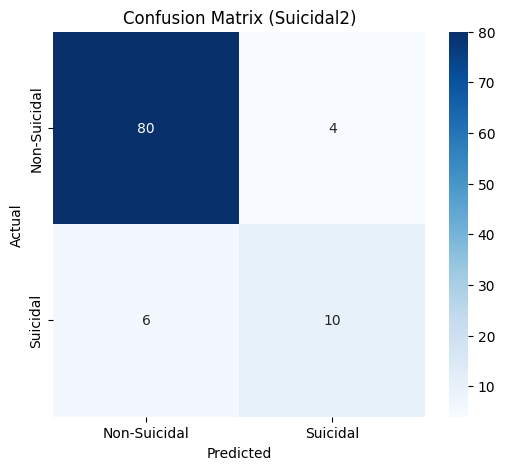

In [70]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Suicidal2)')
plt.show()

In [71]:
text = ("I am feeling very overwhelmed and hopeless lately.", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I have nothing left to live fr... i just want to end this and sleep forever!", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I’m not planning anything, but if a car suddenly swerved toward me today, I wouldn't move out of the way.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I am moving to the edge of the cliff, i have to do this for the betterment of others... i have to jmp frm here, i shall join the squad back after i respawn.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("I want to die.", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("Just another bad day at work!", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("meet me at the battle arena, if i can't prove as MVP i shall commit suicide...", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("Broo! frr what u say this???? i hrd SSR commited suicide!", "Non-Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

text = ("""everyday i start out, then i cry my heart out, lonely is a man without love... - suits so damn well, but this phrasal life is becoming too
suffocating now and i don't think i can make myself work with this on this world anymore... its just too much! when u feel such words depressing, uk the end is near :)""", "Suicidal")
result = predict(text[0], model, tokenizer, id2label)
print(f"Prediction: {result} | {text[1]}")

Prediction: Non-Suicidal | Non-Suicidal
Prediction: Suicidal | Suicidal
Prediction: Suicidal | Suicidal
Prediction: Non-Suicidal | Suicidal
Prediction: Suicidal | Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Non-Suicidal
Prediction: Non-Suicidal | Suicidal


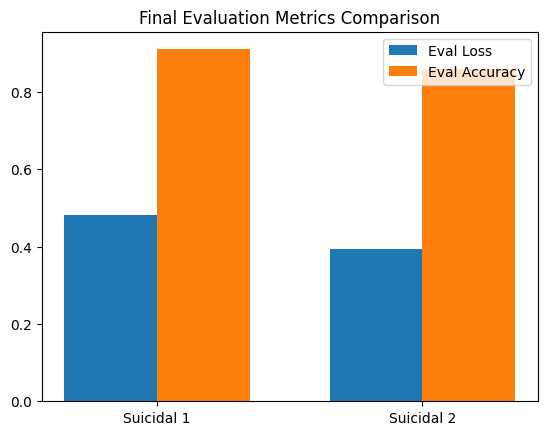

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Take LAST values (final performance)
final_loss_1 = loss_1[-1]
final_acc_1 = acc_1[-1]

final_loss_2 = loss_2[-1]
final_acc_2 = acc_2[-1]

labels = ['Suicidal 1', 'Suicidal 2']

loss_values = [final_loss_1, final_loss_2]
acc_values = [final_acc_1, final_acc_2]

x = np.arange(len(labels))
width = 0.35

plt.figure()

# Bars
plt.bar(x - width/2, loss_values, width, label='Eval Loss')
plt.bar(x + width/2, acc_values, width, label='Eval Accuracy')

plt.xticks(x, labels)
plt.title('Final Evaluation Metrics Comparison')
plt.legend()

plt.show()